## Importing Libraries

First, we import the necessary libraries for data manipulation, downloading financial data, and plotting.

In [2]:
import pandas as pd
from utils import plot_rolling_mean

Here is a breakdown of the libraries being used:
- **pandas**: For data manipulation and analysis.
- **plot_rolling_mean**: A custom function (from the `utils` module) that is used for plotting cumulative and rolling mean returns.

## Loading S&P500 Futures Data

We load the S&P500 futures data from a CSV file.

In [3]:
prices = pd.read_csv("Data/sp500.csv", index_col=0, parse_dates=True)

In [4]:
prices.head()

,Adj Close
Date,
2000-09-18,1467.5
2000-09-19,1478.5
2000-09-20,1469.5
2000-09-21,1469.5
2000-09-22,1468.5


We use `pd.read_csv()` to load the S&P500 futures data from `sp500.csv`. The `index_col=0` parameter sets the first column as the index, and `parse_dates=True` ensures that the index is interpreted as dates, which is essential for time series data.

## Computing Daily Returns

Next, we calculate the daily percentage changes in the S&P500 futures prices to get the daily returns.

In [6]:
returns = prices.pct_change()
returns.head()

,Adj Close
Date,
2000-09-18,NaN
2000-09-19,0.007496
2000-09-20,-0.006087
2000-09-21,0.000000
2000-09-22,-0.000681


## Calculating Cumulative Returns

We calculate the cumulative returns over the period using the daily returns.

In [13]:
cumulative_returns = (1 + returns).cumprod()

In [14]:
cumulative_returns.head()

,Adj Close
Date,
2000-09-18,NaN
2000-09-19,1.007496
2000-09-20,1.001363
2000-09-21,1.001363
2000-09-22,1.000681


By adding 1 to the daily returns and taking the cumulative product, we compute the cumulative returns. This gives us the total return over time, assuming the returns are compounded daily.

## Calculating Rolling Annualized Mean Returns

We calculate the rolling mean returns over different time periods (1 year, 3 years, and 10 years). The rolling mean return provides a smoothed return by averaging over a rolling window of a specified size.

In [17]:
average_yearly_trading_days = 252

rolling_mean_1yr = (
    returns.rolling(window=average_yearly_trading_days).mean()
    * average_yearly_trading_days
)  # 1 year
rolling_mean_3yrs = (
    returns.rolling(window=average_yearly_trading_days * 3).mean()
    * average_yearly_trading_days
)  # 3 year
rolling_mean_10yrs = (
    returns.rolling(window=average_yearly_trading_days * 10).mean()
    * average_yearly_trading_days
)  # 10 year

Here is how we calculate the rolling mean returns:
- **1-year rolling mean**: We use a window size of 252 trading days (which is approximately one year of trading) and annualize the result by multiplying by 252.
- **3-year rolling mean**: We use a window size of 756 trading days (3 years of trading).
- **10-year rolling mean**: We use a window size of 2520 trading days (10 years of trading).

The rolling means are annualized by multiplying by 252 (the number of trading days in a year).

## Plotting the Results

Finally, we use a custom plotting function `plot_rolling_mean()` to plot the cumulative returns along with the rolling mean returns for the different time windows.

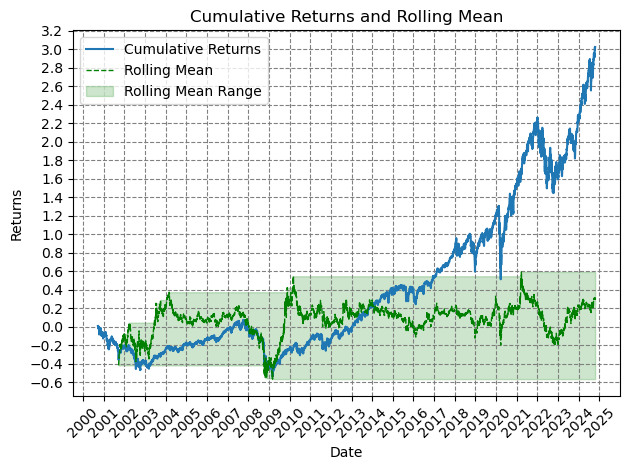

In [19]:
plot_rolling_mean(cumulative_returns, rolling_mean_1yr)

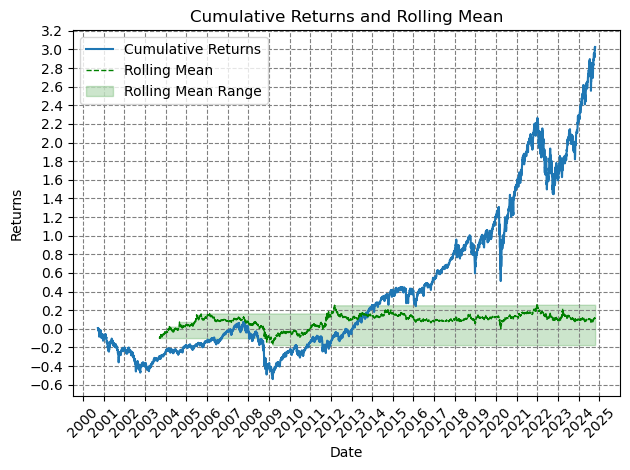

In [20]:
plot_rolling_mean(cumulative_returns, rolling_mean_3yrs)

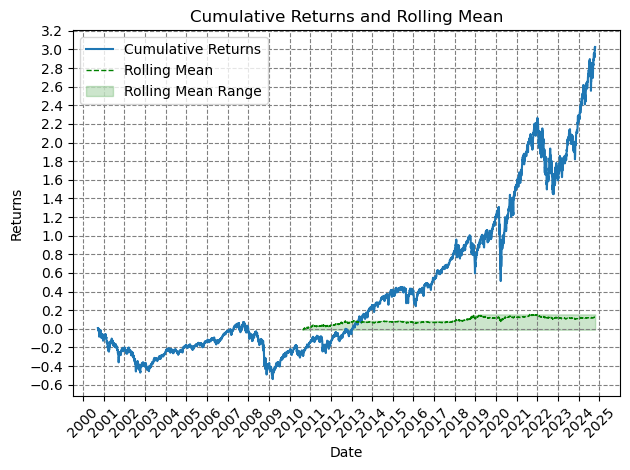

In [21]:
plot_rolling_mean(cumulative_returns, rolling_mean_10yrs)

The `plot_rolling_mean()` function is used to plot the cumulative returns and overlay the rolling mean returns for 1-year, 3-year, and 10-year periods. This allows us to visually compare the smoothed returns over different time horizons.